In [77]:
import numpy as np
from scipy.io import loadmat,savemat
import matplotlib.pyplot as plt
from scipy.special import sph_harm
from einops import rearrange
import nibabel as nib

In [153]:
# Load NIfTI file
img = nib.load('5T_PG_nii\hertz\lq_dic_pg_nii\lq_dic_pg_deltB0_ppm.nii')
B0_data = img.get_fdata()
affine = img.affine
dims = B0_data.shape

# Generate voxel indices (i, j, k) for the entire volume
voxel_indices = np.array(np.meshgrid(np.arange(dims[0]), np.arange(dims[1]), np.arange(dims[2]), indexing='ij'))
voxel_indices = voxel_indices.reshape(3, -1).T
print(voxel_indices.shape)
# affine transform
voxel_indices_h = np.c_[voxel_indices, np.ones(voxel_indices.shape[0])]
world_coords = voxel_indices_h.dot(affine.T)
# save x y z
world_coords = world_coords[:, :3]
threshold = 1e-4
B0_data[np.abs(B0_data) < threshold] = 0
X = world_coords[:, 0].reshape(dims)
Y = world_coords[:, 1].reshape(dims)
Z = world_coords[:, 2].reshape(dims)

savemat('B0_map_shim_lq.mat', {'B0_map': B0_data, 'X': X / 1000, 'Y': Y / 1000, 'Z': Z / 1000})


(1556280, 3)


<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\mgzsz\AppData\Local\Temp\ipykernel_9044\2986975549.py:2: SyntaxWarning: invalid escape sequence '\h'
  img = nib.load('5T_PG_nii\hertz\lq_dic_pg_nii\lq_dic_pg_deltB0_ppm.nii')


In [154]:
B0_map = loadmat("B0_map_shim_lq.mat")
B0_data= np.flip(rearrange(np.asarray(B0_map['B0_map']), "x y z -> x y z"), axis=0)
vox_pos = np.asarray([B0_map['Y'], B0_map['X'], B0_map['Z']])

print(B0_data.shape, vox_pos.shape)
B0_data[B0_data==0] = np.nan
valid_idx = np.argwhere(~np.isnan(B0_data))
B0_data_valid = B0_data[valid_idx[:, 0], valid_idx[:, 1], valid_idx[:, 2]] 

# valid voxel (X, Y, Z)
valid_pos = vox_pos[:, valid_idx[:, 0], valid_idx[:, 1], valid_idx[:, 2]]



savemat('B0_map_shim_lq_valid.mat', {
    'B0_data': B0_data_valid,  
    'X': valid_pos[0],            
    'Y': valid_pos[1],             
    'Z': valid_pos[2]               
})

(132, 131, 90) (3, 132, 131, 90)


In [155]:
def cartesian2spherical(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z/r)
    phi = np.arctan2(y, x)
    return r, theta, phi

def spherical2cartesian(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return x, y, z

def spherical_harmonic(pos, ord, deg):
    x,y,z = pos[0], pos[1], pos[2]
    r, theta, phi = cartesian2spherical(x, y, z)
    return sph_harm(ord, deg, phi, theta)*(r**deg)

In [169]:
X,Y,Z = loadmat("B0_map_noshim_lq_valid.mat")['X'], loadmat("B0_map_noshim_lq_valid.mat")['Y'], loadmat("B0_map_noshim_lq_valid.mat")['Z']
pos = np.vstack([X,Y,Z])
R00 = spherical_harmonic(pos, 0, 0)
R_11 = spherical_harmonic(pos, -1, 1)
R01 = spherical_harmonic(pos, 0, 1)
R11 = spherical_harmonic(pos, 1, 1)
R_22 = spherical_harmonic(pos, -2, 2)
R_12 = spherical_harmonic(pos, -1, 2)
R02 = spherical_harmonic(pos, 0, 2)
R12 = spherical_harmonic(pos, 1, 2)
R22 = spherical_harmonic(pos, 2, 2)
R_33 = spherical_harmonic(pos, -3, 3)
R_23 = spherical_harmonic(pos, -2, 3)
R_13 = spherical_harmonic(pos, -1, 3)
R03 = spherical_harmonic(pos, 0, 3)
R13 = spherical_harmonic(pos, 1, 3)
R23 = spherical_harmonic(pos, 2, 3)
R33 = spherical_harmonic(pos, 3, 3)

In [158]:
X,Y,Z = loadmat("B0_map_shim_lq_valid.mat")['X'], loadmat("B0_map_shim_lq_valid.mat")['Y'], loadmat("B0_map_shim_lq_valid.mat")['Z']
pos = np.vstack([X,Y,Z])
R00_shim = spherical_harmonic(pos, 0, 0)
R_11_shim = spherical_harmonic(pos, -1, 1)
R01_shim = spherical_harmonic(pos, 0, 1)
R11_shim = spherical_harmonic(pos, 1, 1)
R_22_shim = spherical_harmonic(pos, -2, 2)
R_12_shim = spherical_harmonic(pos, -1, 2)
R02_shim = spherical_harmonic(pos, 0, 2)
R12_shim = spherical_harmonic(pos, 1, 2)
R22_shim = spherical_harmonic(pos, 2, 2)
R_33_shim = spherical_harmonic(pos, -3, 3)
R_23_shim = spherical_harmonic(pos, -2, 3)
R_13_shim = spherical_harmonic(pos, -1, 3)
R03_shim = spherical_harmonic(pos, 0, 3)
R13_shim = spherical_harmonic(pos, 1, 3)
R23_shim = spherical_harmonic(pos, 2, 3)
R33_shim = spherical_harmonic(pos, 3, 3)

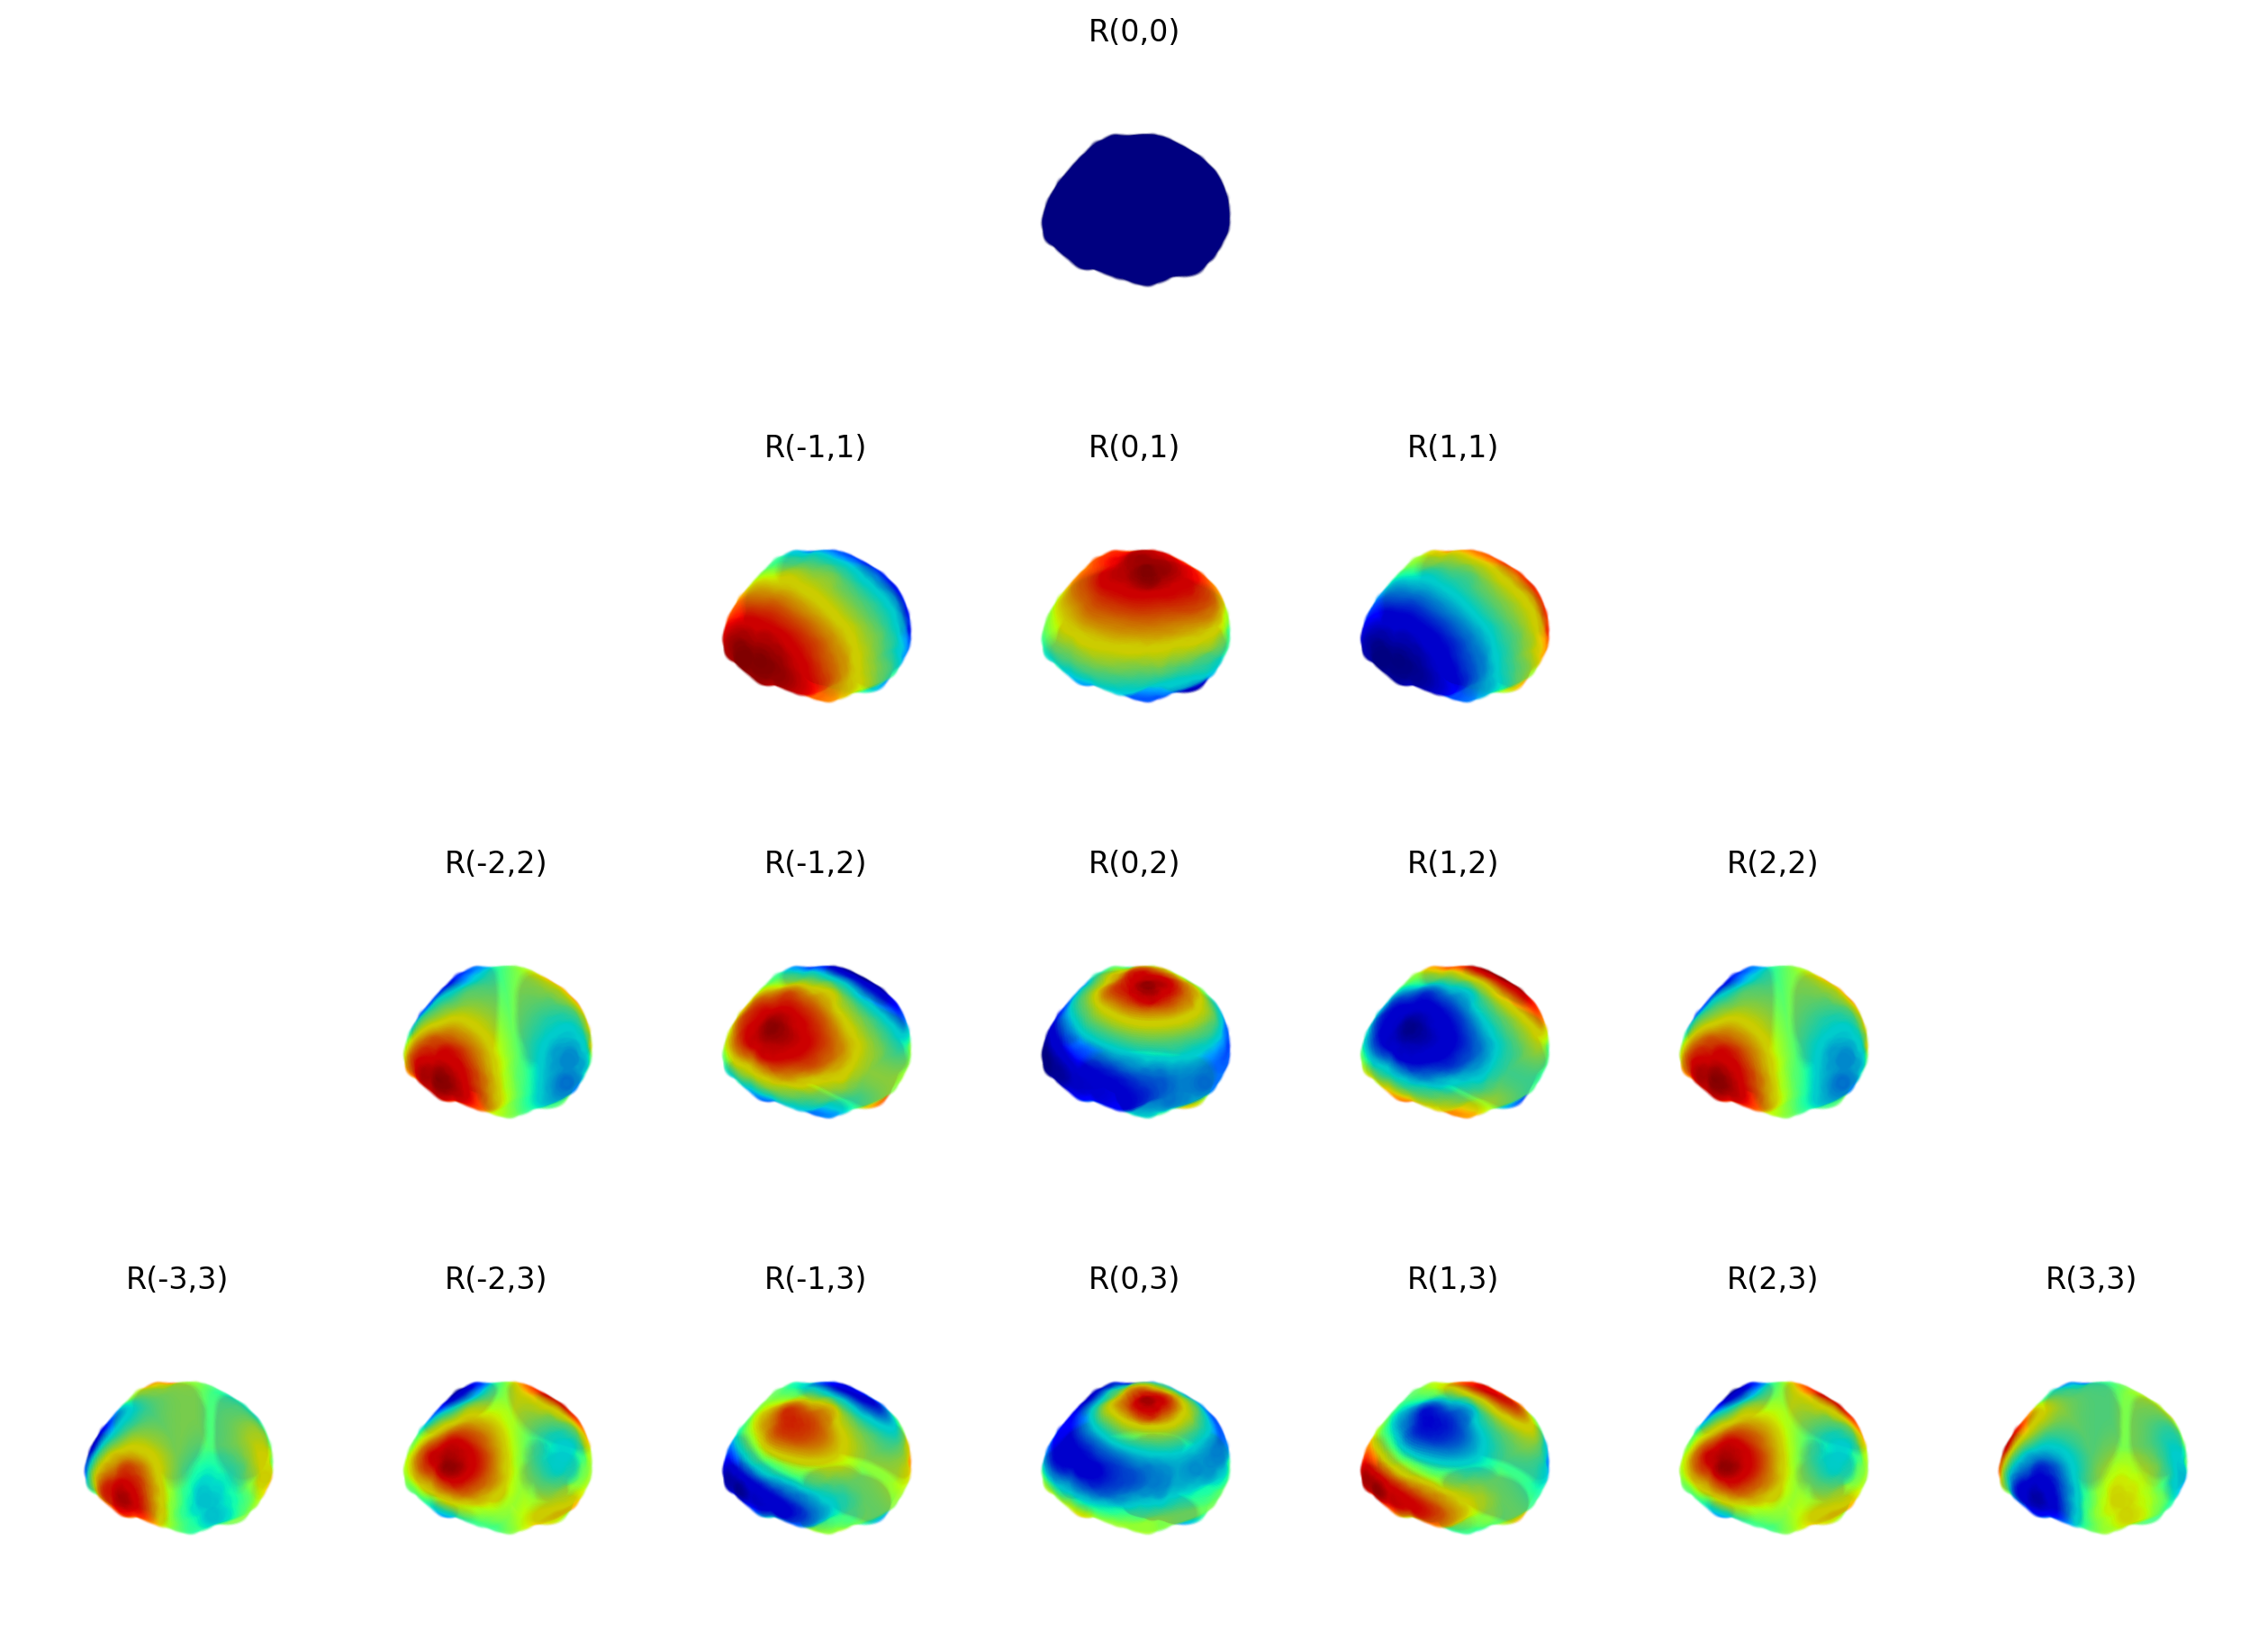

In [174]:
fig = plt.figure(dpi=200,figsize=(16,12))

ax = fig.add_subplot(4,7,4,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R00), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(0,0)')
ax.axis('off')

ax = fig.add_subplot(4,7,10,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R_11), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(-1,1)')
ax.axis('off')

ax = fig.add_subplot(4,7,11,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R01), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(0,1)')
ax.axis('off')

ax = fig.add_subplot(4,7,12,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R11), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(1,1)')
ax.axis('off')

ax = fig.add_subplot(4,7,16,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R_22), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(-2,2)')
ax.axis('off')

ax = fig.add_subplot(4,7,17,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R_12), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(-1,2)')
ax.axis('off')

ax = fig.add_subplot(4,7,18,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R02), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(0,2)')
ax.axis('off')

ax = fig.add_subplot(4,7,19,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R12), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(1,2)')
ax.axis('off')

ax = fig.add_subplot(4,7,20,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R22), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(2,2)')
ax.axis('off')

ax = fig.add_subplot(4,7,22,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R_33), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(-3,3)')
ax.axis('off')

ax = fig.add_subplot(4,7,23,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R_23), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(-2,3)')
ax.axis('off')

ax = fig.add_subplot(4,7,24,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R_13), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(-1,3)')
ax.axis('off')

ax = fig.add_subplot(4,7,25,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R03), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(0,3)')
ax.axis('off')

ax = fig.add_subplot(4,7,26,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R13), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(1,3)')
ax.axis('off')

ax = fig.add_subplot(4,7,27,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R23), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(2,3)')
ax.axis('off')

ax = fig.add_subplot(4,7,28,projection='3d')
ax.scatter(pos[0], pos[1], pos[2], alpha=0.02, c=np.real(R33), cmap='jet')
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('R(3,3)')
ax.axis('off')
plt.subplots_adjust(hspace=0.001, wspace=0.001)

plt.show()

In [161]:
B0_no_shim = loadmat('B0_map_noshim_lq_valid.mat')['B0_data']
B0_shim = loadmat('B0_map_shim_lq_valid.mat')['B0_data']

In [162]:
def coeff_Spherical_Harmonics_2nd(B0_map):
    R = np.vstack([R00, R_11, R01, R11, R_22, R_12, R02, R12, R22,R_33, R_23, R_13, R03, R13, R23, R33])
    return R@B0_map.T

coeff_no_shim = coeff_Spherical_Harmonics_2nd(B0_no_shim)

In [165]:
def coeff_Spherical_Harmonics_2nd_shim(B0_map):
    R = np.vstack([R00_shim, R_11_shim, R01_shim, R11_shim, R_22_shim, R_12_shim, R02_shim, R12_shim, R22_shim, R_33_shim, R_23_shim, R_13_shim, R03_shim, R13_shim, R23_shim, R33_shim])
    return R@B0_map.T

coeff_ear_shim = coeff_Spherical_Harmonics_2nd_shim(B0_shim)

In [167]:
def print_table(first,coeff):
    print("\n|", first, end = " | ")
    for i in range(16):
        print("{:.3f}".format(float(np.abs(coeff[i]))),end=" | ")
print_table("No Shim",coeff_no_shim)
print_table("Ear Shim",coeff_system_shim)


| No Shim | 17756.127 | 481.596 | 575.534 | 481.596 | 23.922 | 9.132 | 34.922 | 9.132 | 23.922 | 1.086 | 1.104 | 1.590 | 3.546 | 1.590 | 1.104 | 1.086 | 
| Ear Shim | 11131.334 | 613.702 | 557.933 | 613.702 | 26.696 | 13.097 | 7.709 | 13.097 | 26.696 | 1.139 | 0.813 | 2.321 | 3.614 | 2.321 | 0.813 | 1.139 | 

C:\Users\mgzsz\AppData\Local\Temp\ipykernel_9044\1076585316.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("{:.3f}".format(float(np.abs(coeff[i]))),end=" | ")


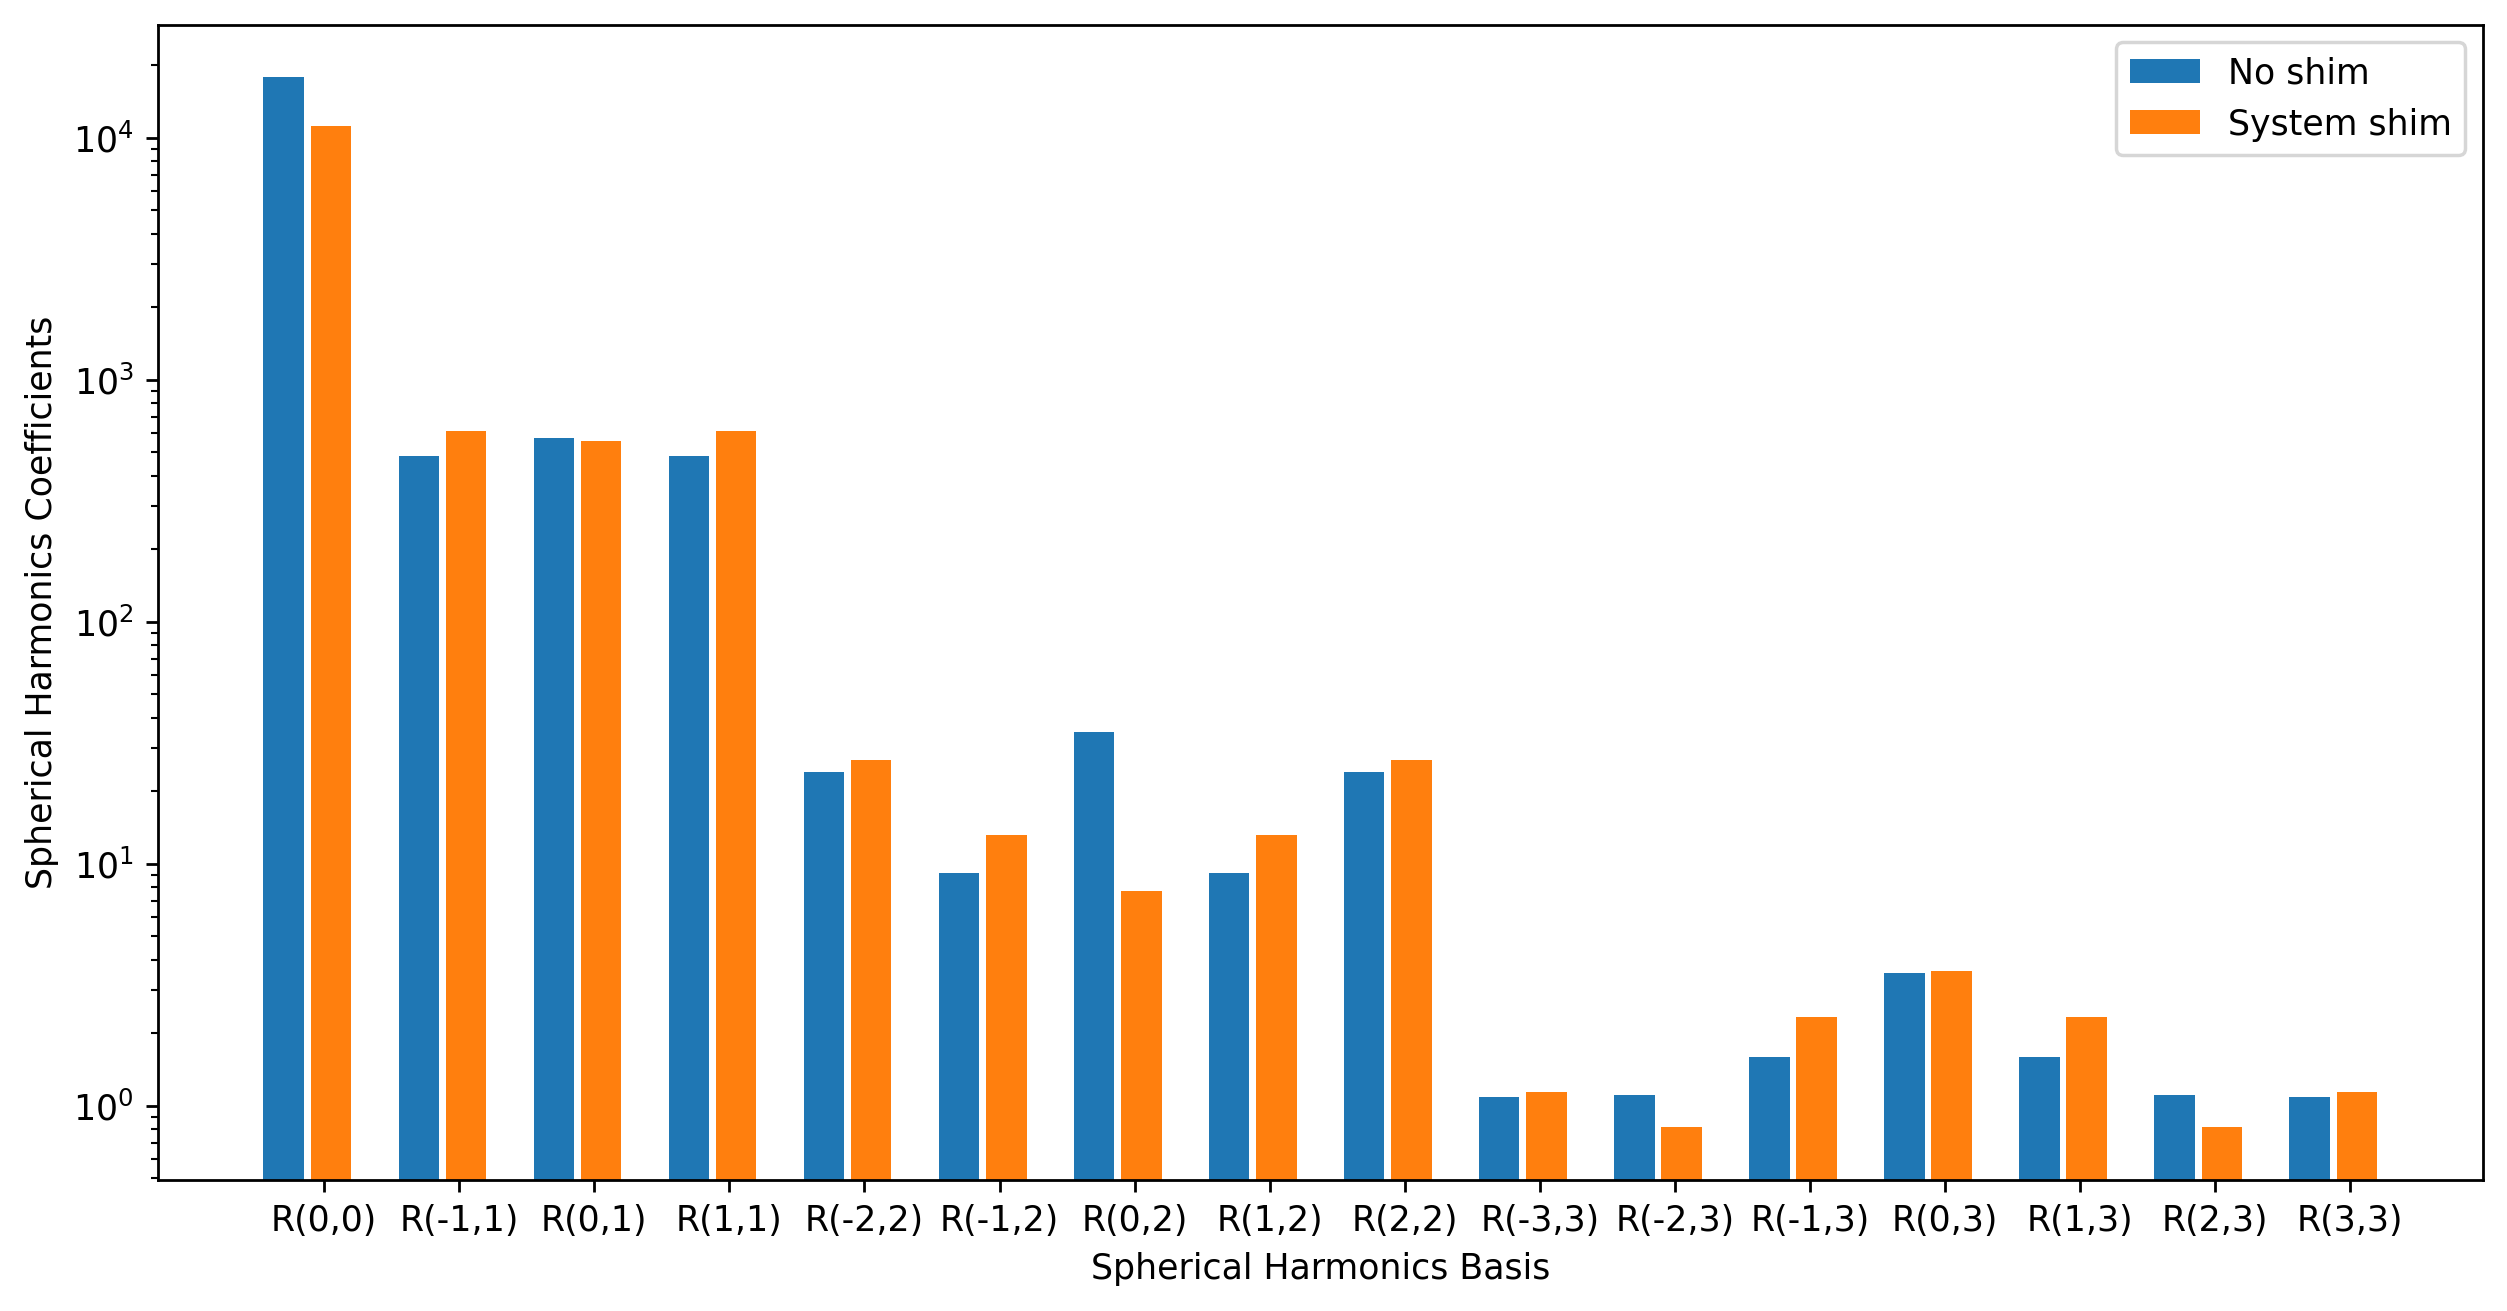

In [ ]:
plt.figure(figsize=(12,6),dpi=250)
plt.bar(np.arange(16), np.abs(coeff_no_shim).flatten(), width=0.3, label='No shim')
plt.bar(np.arange(16)+0.35, np.abs(coeff_ear_shim).flatten(), width=0.3, label='Ear shim')
plt.yscale('log')
plt.xticks(np.arange(16)+0.3, ['R(0,0)', 'R(-1,1)', 'R(0,1)', 'R(1,1)', 'R(-2,2)', 'R(-1,2)', 'R(0,2)', 'R(1,2)', 'R(2,2)', 'R(-3,3)', 'R(-2,3)', 'R(-1,3)', 'R(0,3)', 'R(1,3)', 'R(2,3)', 'R(3,3)'])
plt.ylabel('Spherical Harmonics Coefficients')
plt.xlabel('Spherical Harmonics Basis')
plt.legend()
plt.show()